In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/adhdata.csv")

In [3]:
df.shape

(2166383, 21)

In [4]:
df.columns.tolist()

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T7',
 'T8',
 'P7',
 'P8',
 'Fz',
 'Cz',
 'Pz',
 'Class',
 'ID']

In [5]:
df['Class']

0             ADHD
1             ADHD
2             ADHD
3             ADHD
4             ADHD
            ...   
2166378    Control
2166379    Control
2166380    Control
2166381    Control
2166382    Control
Name: Class, Length: 2166383, dtype: str

In [6]:
df.dtypes

Fp1      float64
Fp2      float64
F3       float64
F4       float64
C3       float64
C4       float64
P3       float64
P4       float64
O1       float64
O2       float64
F7       float64
F8       float64
T7       float64
T8       float64
P7       float64
P8       float64
Fz       float64
Cz       float64
Pz       float64
Class        str
ID           str
dtype: object

In [7]:
df.head()

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,...,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,...,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,...,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,...,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,...,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p


In [8]:
df['Class'].value_counts()

Class
ADHD       1207069
Control     959314
Name: count, dtype: int64

In [9]:
df['ID'].nunique()

121

In [10]:
print(df.duplicated().sum())
print(df.duplicated().mean() * 100)

45
0.002077195029687733


usuwam duplikaty bo jest ich malo - raczej bledy zamast prawdziwych pomiarow

In [11]:
df = df.drop_duplicates()

In [12]:
df.count()

Fp1      2166338
Fp2      2166338
F3       2166338
F4       2166338
C3       2166338
C4       2166338
P3       2166338
P4       2166338
O1       2166338
O2       2166338
F7       2166338
F8       2166338
T7       2166338
T8       2166338
P7       2166338
P8       2166338
Fz       2166338
Cz       2166338
Pz       2166338
Class    2166338
ID       2166338
dtype: int64

In [13]:
df.isnull().sum()

Fp1      0
Fp2      0
F3       0
F4       0
C3       0
C4       0
P3       0
P4       0
O1       0
O2       0
F7       0
F8       0
T7       0
T8       0
P7       0
P8       0
Fz       0
Cz       0
Pz       0
Class    0
ID       0
dtype: int64

In [14]:
df.isna().sum()

Fp1      0
Fp2      0
F3       0
F4       0
C3       0
C4       0
P3       0
P4       0
O1       0
O2       0
F7       0
F8       0
T7       0
T8       0
P7       0
P8       0
Fz       0
Cz       0
Pz       0
Class    0
ID       0
dtype: int64

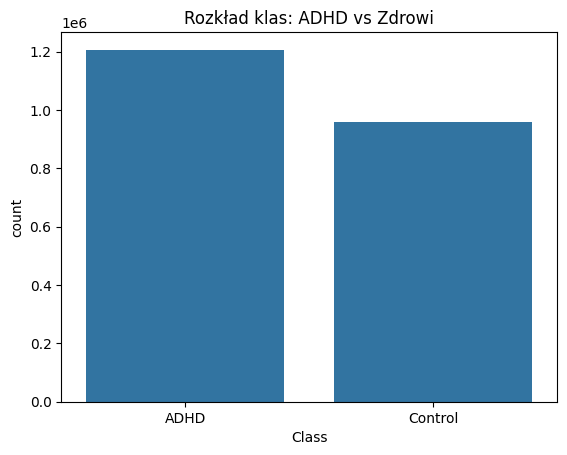

In [15]:
sns.countplot(x='Class', data=df)
plt.title('Rozkład klas: ADHD vs Zdrowi')
plt.show()

proporcja około 56%/44% - spoko

In [16]:
samples_per_patient = df.groupby('ID').size()
samples_per_patient.describe()

count      121.000000
mean     17903.619835
std       6207.081515
min       7983.000000
25%      13697.000000
50%      16697.000000
75%      20101.000000
max      43252.000000
dtype: float64

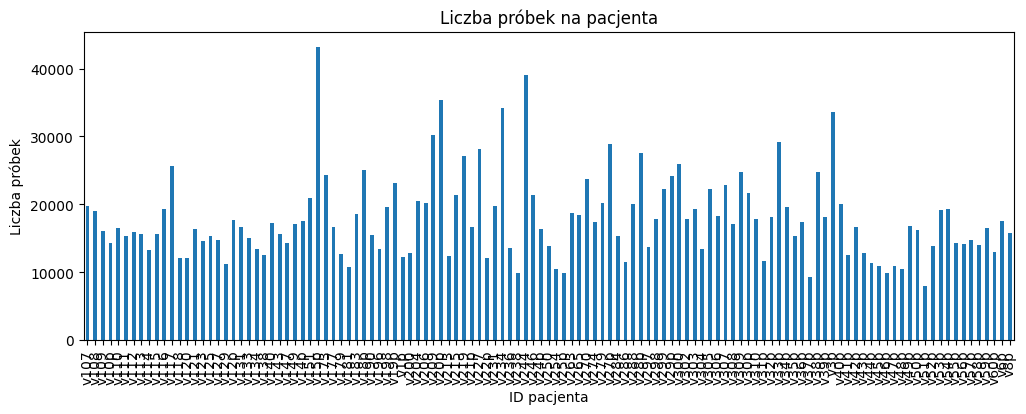

In [17]:
samples_per_patient.plot(kind='bar', figsize=(12,4))
plt.title('Liczba próbek na pacjenta')
plt.xlabel('ID pacjenta')
plt.ylabel('Liczba próbek')
plt.show()

duże różnice w liczbie próbek - agregacja cech

In [18]:
adhd_patient = df[df['Class'] == 'ADHD']['ID'].iloc[0]
healthy_patient = df[df['Class'] == 'Control']['ID'].iloc[0]

eeg_channels = [col for col in df.columns if col not in ['ID', 'Class']]
channel = eeg_channels[0]

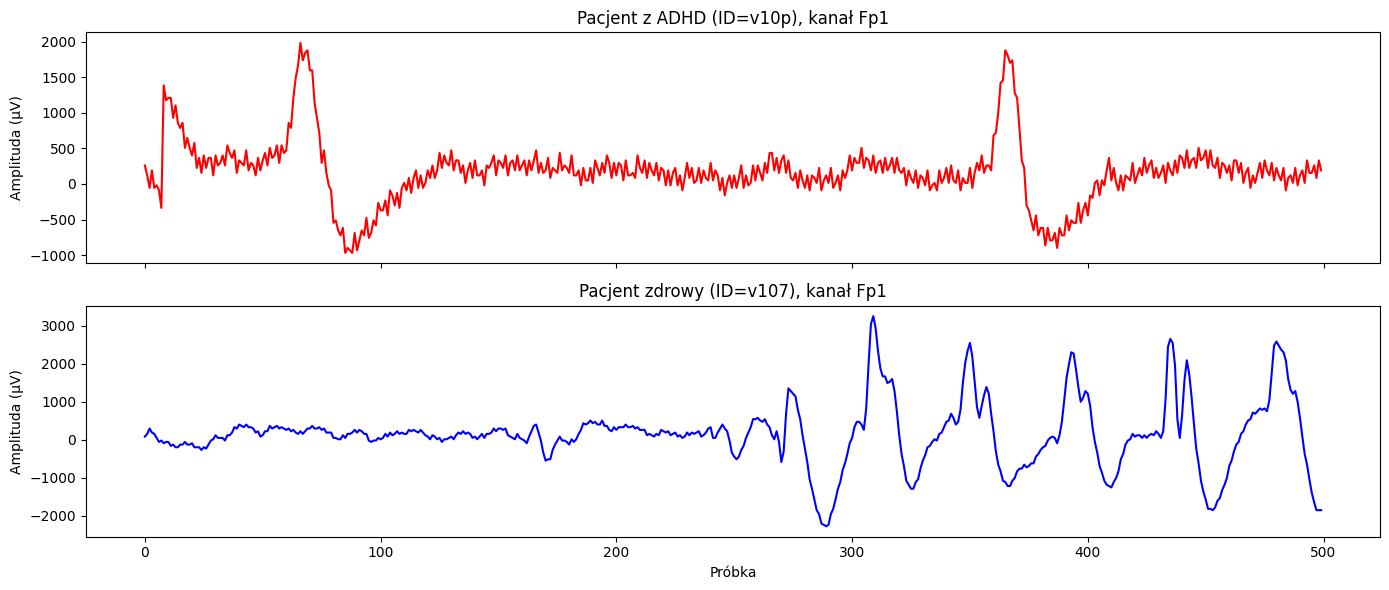

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14,6), sharex=True)

adhd_signal = df[df['ID'] == adhd_patient][channel].values[:500]
axes[0].plot(adhd_signal, color='red')
axes[0].set_title(f'Pacjent z ADHD (ID={adhd_patient}), kanał {channel}')
axes[0].set_ylabel('Amplituda (µV)')

healthy_signal = df[df['ID'] == healthy_patient][channel].values[:500]
axes[1].plot(healthy_signal, color='blue')
axes[1].set_title(f'Pacjent zdrowy (ID={healthy_patient}), kanał {channel}')
axes[1].set_ylabel('Amplituda (µV)')
axes[1].set_xlabel('Próbka')

plt.tight_layout()
plt.show()

In [20]:
eeg_stats = df[eeg_channels].describe()
print(eeg_stats)

                Fp1           Fp2            F3            F4            C3  \
count  2.166338e+06  2.166338e+06  2.166338e+06  2.166338e+06  2.166338e+06   
mean   1.360881e+02  1.361673e+02  1.422080e+02  1.361057e+02  1.422711e+02   
std    2.755461e+02  2.755105e+02  2.206457e+02  2.133850e+02  2.234801e+02   
min   -3.786000e+03 -1.322400e+04 -3.921000e+03 -1.323700e+04 -3.921000e+03   
25%    1.500000e+01  1.500000e+01  5.200000e+01  1.500000e+01  5.200000e+01   
50%    1.210000e+02  1.210000e+02  1.260000e+02  1.210000e+02  1.260000e+02   
75%    2.610000e+02  2.260000e+02  2.360000e+02  2.260000e+02  2.360000e+02   
max    1.381300e+04  4.802000e+03  5.020000e+03  4.802000e+03  5.430000e+03   

                 C4            P3            P4            O1            O2  \
count  2.166338e+06  2.166338e+06  2.166338e+06  2.166338e+06  2.166338e+06   
mean   1.422047e+02  1.422741e+02  1.419658e+02  1.420029e+02  1.416067e+02   
std    2.107162e+02  2.301820e+02  2.095654e+02  2.

In [21]:
mean_by_class = df.groupby('Class')[eeg_channels].mean()
print(mean_by_class)

                Fp1         Fp2          F3          F4          C3  \
Class                                                                 
ADHD     136.214545  136.289382  142.264480  136.170162  142.347010   
Control  135.929072  136.013727  142.137015  136.024510  142.175637   

                 C4          P3          P4          O1          O2  \
Class                                                                 
ADHD     142.257892  142.354722  142.039563  142.102805  141.601773   
Control  142.137874  142.172644  141.873090  141.877170  141.612967   

                 F7          F8          T7          T8          P7  \
Class                                                                 
ADHD     142.189467  141.531734  141.822946  141.264655  141.683016   
Control  141.886751  141.610903  141.635696  141.396212  141.618095   

                 P8          Fz          Cz          Pz  
Class                                                    
ADHD     140.979356  135.0840

nie widac zadnej znaczacej roznicy

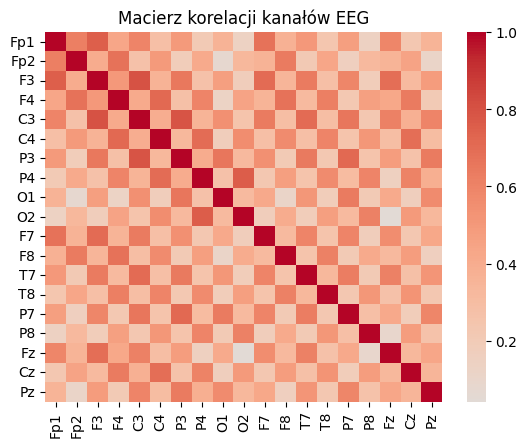

In [22]:
corr_matrix = df[eeg_channels].corr()

plt.figure()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Macierz korelacji kanałów EEG')
plt.show()

wysoka korelacja elektrod blisko siebie (np. F4-F8, P3-P7 ) - spodziewane. nie ma wartosci ujemnych - nie pracują w przeciwnych kierunkach

In [23]:
from scipy.signal import welch

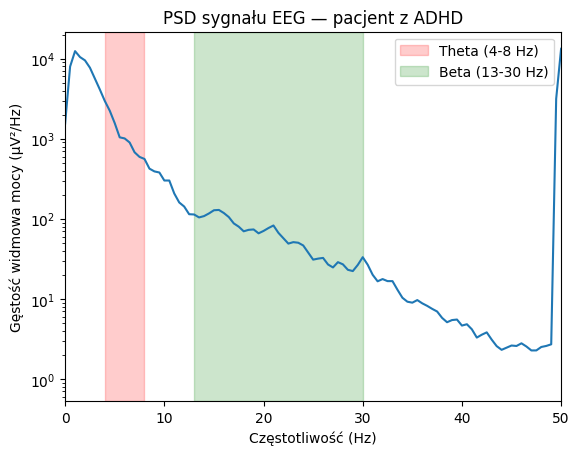

In [26]:
signal = df[df['ID'] == adhd_patient][channel].values
fs = 128 

freqs, psd = welch(signal, fs=fs, nperseg=256)

plt.figure()
plt.semilogy(freqs, psd)
plt.xlabel('Częstotliwość (Hz)')
plt.ylabel('Gęstość widmowa mocy (µV²/Hz)')
plt.title('PSD sygnału EEG — pacjent z ADHD')
plt.axvspan(4, 8, alpha=0.2, color='red', label='Theta (4-8 Hz)')
plt.axvspan(13, 30, alpha=0.2, color='green', label='Beta (13-30 Hz)')
plt.legend()
plt.xlim(0, 50)
plt.show()

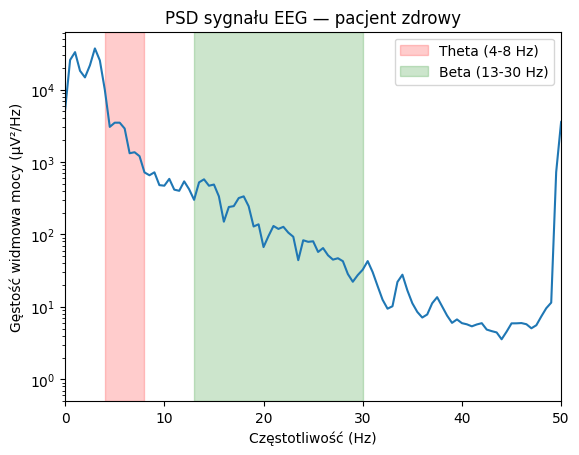

In [28]:
signal1 = df[df['ID'] == healthy_patient][channel].values

freqs, psd = welch(signal1, fs=fs, nperseg=256)

plt.figure()
plt.semilogy(freqs, psd)
plt.xlabel('Częstotliwość (Hz)')
plt.ylabel('Gęstość widmowa mocy (µV²/Hz)')
plt.title('PSD sygnału EEG — pacjent zdrowy')
plt.axvspan(4, 8, alpha=0.2, color='red', label='Theta (4-8 Hz)')
plt.axvspan(13, 30, alpha=0.2, color='green', label='Beta (13-30 Hz)')
plt.legend()
plt.xlim(0, 50)
plt.show()

na podstawie osobnych wykresów dla pojedynczego pacjenta nie widać zauważalnych wniosków

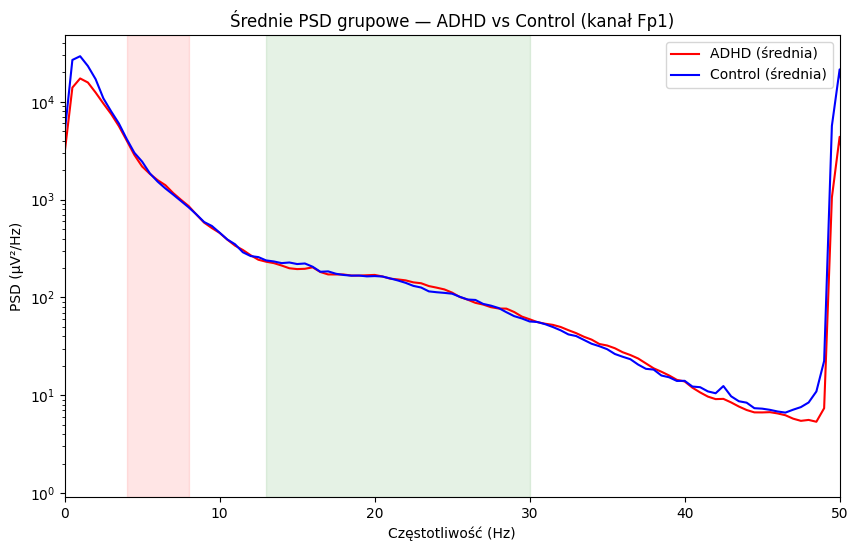

In [34]:
import numpy as np
all_psds = {'ADHD': [], 'Control': []}

for pid in df['ID'].unique():
    patient_data = df[df['ID'] == pid]
    cls = patient_data['Class'].iloc[0]
    signal = patient_data[channel].values
    freqs, psd = welch(signal, fs=fs, nperseg=256)
    all_psds[cls].append(psd)

mean_adhd = np.mean(all_psds['ADHD'], axis=0)
mean_ctrl = np.mean(all_psds['Control'], axis=0)

plt.figure(figsize=(10, 6))
plt.semilogy(freqs, mean_adhd, label='ADHD (średnia)', color='red')
plt.semilogy(freqs, mean_ctrl, label='Control (średnia)', color='blue')
plt.axvspan(4, 8, alpha=0.1, color='red')
plt.axvspan(13, 30, alpha=0.1, color='green')
plt.xlabel('Częstotliwość (Hz)')
plt.ylabel('PSD (µV²/Hz)')
plt.title(f'Średnie PSD grupowe — ADHD vs Control (kanał {channel})')
plt.legend()
plt.xlim(0, 50)
plt.show()

dla grupowego wykresu dla kanału Fp1 nie widać róźnicy -> band power nie rozróżnia klas oraz porównanie pojedynczych pacjentów jest mylące - duża zmienność międzyosobnicza

wnioski:
- średnie kanałów identyczne między klasami - proste statystyki nie pomogą
- psd grupowe i tbr pokrywają się - też nie będą użyteczne :(
- wysoka korelacja sąsiednich elektrod - możliwa redundancja
- duże różnice w liczbie próbek na pacjenta - potrzebna segmentacja stałej długości
- brak braków danych :)

potrzebujemy cech, które wychwycą rozproszone różnice - entropia, koherencja, asymetria lub deep-learning żeby samo znalazło 